In [13]:
import os
import numpy as np
import cv2
from PIL import Image
import random
from tqdm import tqdm
from config import PATH_TEST, PATH_TRAINVAL, SEED, BATCH_SIZE

# ----------------------------
# CONFIGURATION
# ----------------------------
INPUT_IMAGE_DIR = "./path_to_dataset/color"
INPUT_MASK_DIR = "./path_to_dataset/label"



INPUT_IMAGE_DIR = os.path.join(PATH_TRAINVAL, 'color/')
INPUT_MASK_DIR = os.path.join(PATH_TRAINVAL, 'label/')


OUTPUT_DIR = "./point_prompt_dataset"
OUTPUT_IMAGE_DIR = os.path.join(OUTPUT_DIR, "images")
OUTPUT_MASK_DIR = os.path.join(OUTPUT_DIR, "masks")
OUTPUT_PROMPT_DIR = os.path.join(OUTPUT_DIR, "prompts")

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(OUTPUT_MASK_DIR, exist_ok=True)
os.makedirs(OUTPUT_PROMPT_DIR, exist_ok=True)

# ----------------------------
# UTILITY FUNCTIONS
# ----------------------------
def sample_point_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    idx = np.random.randint(len(xs))
    return xs[idx], ys[idx]

def generate_heatmap(point, shape, sigma=5):
    heatmap = np.zeros(shape, dtype=np.float32)
    if point:
        x, y = point
        heatmap[y, x] = 1
        heatmap = cv2.GaussianBlur(heatmap, (0, 0), sigma)
        heatmap = heatmap / np.max(heatmap)
    return heatmap

# ----------------------------
# MAIN LOOP
# ----------------------------
image_list = sorted(os.listdir(INPUT_IMAGE_DIR))
mask_list = sorted(os.listdir(INPUT_MASK_DIR))

for img_name, mask_name in tqdm(zip(image_list, mask_list), total=len(image_list)):
    img_path = os.path.join(INPUT_IMAGE_DIR, img_name)
    mask_path = os.path.join(INPUT_MASK_DIR, mask_name)

    img = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path))
    mask = (mask > 0).astype(np.uint8)  # Convert to binary if necessary

    point = sample_point_from_mask(mask)
    if point is None:
        continue

    heatmap = generate_heatmap(point, mask.shape)

    # Save outputs
    Image.fromarray(img).save(os.path.join(OUTPUT_IMAGE_DIR, img_name))
    Image.fromarray((mask * 255).astype(np.uint8)).save(os.path.join(OUTPUT_MASK_DIR, mask_name))
    np.save(os.path.join(OUTPUT_PROMPT_DIR, mask_name.replace(".png", ".npy")), heatmap)

print("✅ Preprocessing complete: saved images, masks, and prompts.")


100%|██████████| 3673/3673 [00:23<00:00, 153.27it/s]

✅ Preprocessing complete: saved images, masks, and prompts.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


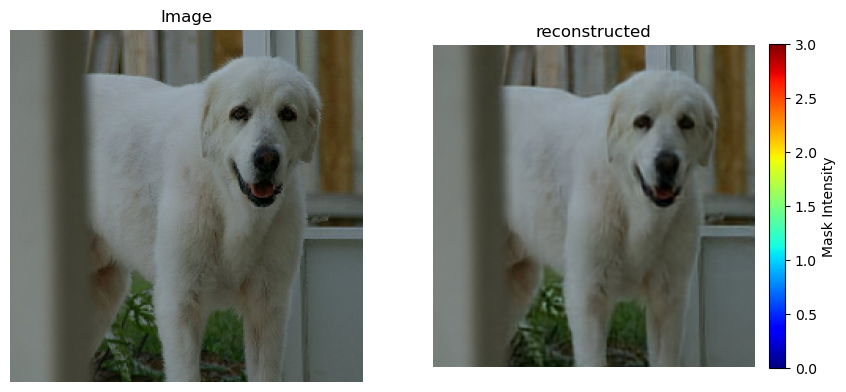

Image shape:  torch.Size([3, 224, 224])
Reconstructed shape:  torch.Size([3, 224, 224])


In [164]:
# Standard libs
import os
import random

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Image processing
import cv2

# PyTorch
import torch
from torch.utils.data import DataLoader
import torchviz
import torch.optim as optim
import torch.nn as nn

# Models
from models.autoencoder import Autoencoder # Implemented Here
from models.unet_model import UNet, ConvBlock, UpsamplingBlock # Implemented Here
from models.prompt_based_unet import PromptUNet # Implemented Here

# Utils and config
from utils import visualize, analyze, training_plot, save_statistics
from Datasets.Segmentation.data_providers import test_dataset, val_dataset, train_dataset
from config import SEED, BATCH_SIZE

# Device setup
device = torch.device("cpu")


from tqdm import tqdm
# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

images, masks, _ = next(iter(val_dataloader))
N=random.randint(0,BATCH_SIZE-1)
unet = UNet()
prompunet = PromptUNet(device=device, n_classes=2)
autoencoder = Autoencoder(input_channels=3, n_filters=64).to(device)
autoencoder.load_state_dict(torch.load("models/weights/autoencoder/autoencoder_weights_0.001509.pth"))
autoencoder.eval()
with torch.no_grad():
    reconstructed = autoencoder(images[N])


visualize(images[N].permute(1, 2, 0).numpy(),reconstructed.permute(1, 2, 0).numpy(),"reconstructed")
print("Image shape: ",images[N].shape)
print("Reconstructed shape: ",reconstructed.shape)

In [92]:
print(prompunet)

PromptUNet(
  (encoder): CLIPResNetFeatureExtractor(
    (clip_encoder): ModifiedResNet(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu3): ReLU(inplace=True)
      (avgpool): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.

In [29]:
print(upsampling)

UpsamplingBlock(
  (upconv): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv1): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
